In [66]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [67]:
data = pd.read_csv('customer_churn_data.csv')
data.head(5)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [68]:
data.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [69]:
data['InternetService'] = data['InternetService'].fillna("")

In [70]:
data.isna().sum()

CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

In [71]:
numeric_column_data = data.select_dtypes(include=["number"])

In [72]:
numeric_column_data

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
0,1,49,4,88.35,353.40
1,2,43,0,36.67,0.00
2,3,51,2,63.79,127.58
3,4,60,8,102.34,818.72
4,5,42,32,69.01,2208.32
...,...,...,...,...,...
995,996,42,41,37.14,1522.74
996,997,62,9,80.93,728.37
997,998,51,15,111.72,1675.80
998,999,39,68,65.67,4465.56


In [73]:
numeric_column_data.corr()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


## strong positive 1 
## strong negative -1 

In [74]:
data['Churn'].value_counts()

Churn
Yes    883
No     117
Name: count, dtype: int64

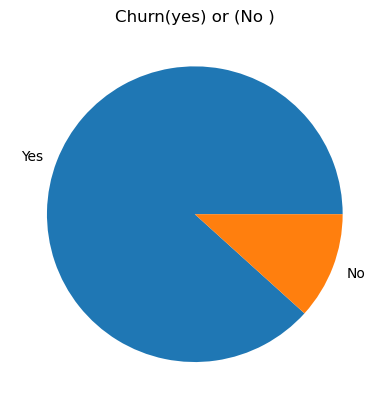

In [75]:
data['Churn'].value_counts().plot(kind='pie')
plt.title("Churn(yes) or (No )")
plt.ylabel("")
plt.show()

In [76]:
data.groupby("Churn")['MonthlyCharges'].mean()

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

In [77]:
data.head(10)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes
5,6,42,Female,16,119.75,Two-Year,DSL,1916.00,Yes,Yes
6,7,60,Male,14,80.32,One-Year,,1124.48,No,Yes
7,8,52,Female,6,58.90,One-Year,,353.40,No,Yes
8,9,40,Female,53,49.81,Two-Year,Fiber Optic,2639.93,Yes,No
9,10,50,Female,10,61.55,Month-to-Month,Fiber Optic,615.50,Yes,Yes


In [78]:
data.groupby(["Churn" ,"Gender"])['MonthlyCharges'].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [79]:
data.groupby("Churn")["Tenure"].mean()

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

In [80]:
data.groupby("ContractType")['MonthlyCharges'].mean()

ContractType
Month-to-Month    75.909198
One-Year          73.822803
Two-Year          71.334500
Name: MonthlyCharges, dtype: float64

### preprocessing data 

In [81]:
y= data[['Churn']] 
x = data[["Age","Gender","Tenure","MonthlyCharges"]]

In [82]:
x

,Age,Gender,Tenure,MonthlyCharges
0,49,Male,4,88.35
1,43,Male,0,36.67
2,51,Female,2,63.79
3,60,Female,8,102.34
4,42,Male,32,69.01
...,...,...,...,...
995,42,Male,41,37.14
996,62,Male,9,80.93
997,51,Female,15,111.72
998,39,Male,68,65.67


In [83]:
y

,Churn
0,Yes
1,Yes
2,Yes
3,Yes
4,Yes
...,...
995,Yes
996,Yes
997,Yes
998,Yes


In [84]:
# x['Gender']=x['Gender'].replace('Female',0)
# x['Gender']=x['Gender'].replace('Male',1)
x["Gender"] = x["Gender"].apply(lambda x:1 if x == "Female" else 0 )

C:\Users\ahmed\AppData\Local\Temp\ipykernel_18652\2357144973.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["Gender"] = x["Gender"].apply(lambda x:1 if x == "Female" else 0 )


/*mow work on Churn to make it 1 or 0  */    

In [90]:
y["Churn"].value_counts() 

Churn
Yes    883
No     117
Name: count, dtype: int64

In [91]:
y["Churn"] = y["Churn"].apply( lambda x: 1 if x == "Yes" else 0 ) 
y["Churn"].value_counts() 

C:\Users\ahmed\AppData\Local\Temp\ipykernel_18652\4133814901.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y["Churn"] = y["Churn"].apply( lambda x: 1 if x == "Yes" else 0 )


Churn
1    883
0    117
Name: count, dtype: int64

In [85]:
x["Gender"].value_counts()

Gender
1    538
0    462
Name: count, dtype: int64

In [88]:
type(x["Gender"][0])

numpy.int64

### modeling 

In [92]:
from sklearn.model_selection import train_test_split 
X_train ,X_test , Y_train , Y_test = train_test_split(x,y,test_size=2)

In [93]:
x

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01
...,...,...,...,...
995,42,0,41,37.14
996,62,0,9,80.93
997,51,1,15,111.72
998,39,0,68,65.67


In [95]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)


In [96]:
X_train

array([[ 2.48608429, -1.07928634, -0.73994218, -1.58886654],
       [ 0.34067728, -1.07928634, -0.84576182, -1.27039712],
       [ 0.13635281,  0.92653818, -0.63412255, -0.58167781],
       ...,
       [-0.37445839, -1.07928634, -0.52830292, -0.5945256 ],
       [-0.98743182,  0.92653818, -0.21084403,  0.49403245],
       [-1.49824301,  0.92653818,  0.26534432, -0.2285583 ]])

In [98]:
import joblib 
joblib.dump(scaler ,"scaler.pkl")

['scaler.pkl']

In [99]:
X_test = scaler.fit_transform(X_test)


In [100]:
X_test

array([[ 1., -1.,  1., -1.],
       [-1.,  1., -1.,  1.]])

In [101]:
X_train

array([[ 2.48608429, -1.07928634, -0.73994218, -1.58886654],
       [ 0.34067728, -1.07928634, -0.84576182, -1.27039712],
       [ 0.13635281,  0.92653818, -0.63412255, -0.58167781],
       ...,
       [-0.37445839, -1.07928634, -0.52830292, -0.5945256 ],
       [-0.98743182,  0.92653818, -0.21084403,  0.49403245],
       [-1.49824301,  0.92653818,  0.26534432, -0.2285583 ]])

## Build Our Model Classification 

In [103]:
from sklearn.metrics import accuracy_score
def modelperformance(predictions):
    print("Accuracy score on model is {}".format(accuracy_score(Y_test,predictions)))


In [108]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
import warnings 
warnings.filterwarnings("ignore")

In [109]:
log_model = LogisticRegression()

In [110]:
log_model.fit(X_train,Y_train)

LogisticRegression()

In [111]:
Y_pred = log_model.predict(X_test)


In [112]:
Y_pred

array([1, 1])

In [113]:
Y_test

,Churn
6,1
277,1


In [114]:
modelperformance(Y_pred)

Accuracy score on model is 1.0


In [115]:
from sklearn.neighbors import KNeighborsClassifier 

param_grid= {
    "n_neighbors":[3,5,7,9],
    "weights" : ["uniform","distance"],
}

In [116]:
gridkn= GridSearchCV(KNeighborsClassifier(),param_grid ,cv=5)

In [117]:
gridkn.fit(X_train,Y_train)


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [118]:
gridkn.best_params_

{'n_neighbors': 7, 'weights': 'distance'}

In [120]:
Y_pred=gridkn.predict(X_test)

In [121]:
modelperformance(Y_pred)

Accuracy score on model is 1.0


In [125]:
best_model = gridkn.best_estimator_
joblib.dump(best_model,"gridkn.pkl")

['gridkn.pkl']